# Datathon 2026 Round 1 — Phase 5: EDA Descriptive & Diagnostic

Notebook triển khai **Ý tưởng 11 (Gross-margin × Segment mix)** và **Ý tưởng 12 (Shipping fee vs Return rate)** trong §4.2 của tài liệu brainstorm nội bộ.

Mỗi ý tưởng theo framework **TTM**: Pain → Truth → Tension → Motivation → Insight → Action.

- Ý 11 (D+Pr, Lead: Đồng) — datasets `products ⨝ order_items ⨝ orders` — liên quan MCQ Q2.
- Ý 12 (Di+Pr, Lead: Kiên) — datasets `shipments ⨝ orders ⨝ returns`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print(f'Pandas {pd.__version__} | Numpy {np.__version__}')

DATA = '../dataset-datathon-2026-round-1/'
FIG = '../outputs/figures/'
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load data
products    = pd.read_csv(DATA + 'products.csv')
orders      = pd.read_csv(DATA + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA + 'order_items.csv', low_memory=False)
shipments   = pd.read_csv(DATA + 'shipments.csv', parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(DATA + 'returns.csv', parse_dates=['return_date'])

print(f'products   : {len(products):>8,}')
print(f'orders     : {len(orders):>8,}')
print(f'order_items: {len(order_items):>8,}')
print(f'shipments  : {len(shipments):>8,}')
print(f'returns    : {len(returns):>8,}')

Pandas 2.2.2 | Numpy 1.26.4


products   :    2,412
orders     :  646,945
order_items:  714,669
shipments  :  566,067
returns    :   39,939


---
## Ý tưởng 11 — Gross-margin × Segment mix

**Pain (đau)**. Ban điều hành nghi ngờ phân khúc **Premium** đang mất sức bật — margin từng là lợi thế chính, nhưng revenue share đã giảm trong chu kỳ 2020–2022.

**Tension (mâu thuẫn)**. Merch team tin rằng thị trường đã chuyển sang "khách trẻ mua Activewear giá rẻ" → dồn ngân sách marketing về Activewear, bỏ quên Premium.

**Motivation (động cơ)**. Nếu Premium vẫn còn khách hàng ngân sách cao nhưng bị bỏ đói marketing, thì mất doanh thu Premium là self-inflicted, không phải do thị trường — có thể đảo ngược.

**Hypothesis cần kiểm định**:
- **H1**: Segment Premium có margin % cao nhất trong 8 phân khúc.
- **H2**: Revenue share của Premium giảm 2020 → 2022.
- **H3**: Phân khúc thống trị revenue lại nằm ở nhóm margin thấp hơn → có khoảng trống để cân bằng lại mix.

### 11.1 Truth — Bảng margin theo segment (kiểm định H1)

             n_skus  mean_margin  median_margin  mean_price
segment                                                    
Standard        262        31.34          37.08     2928.59
Premium         177        28.54          36.05     2387.67
All-weather     169        28.42          34.88     3864.75
Activewear      598        26.56          29.64     2598.10
Performance     347        26.36          30.00     6572.85
Balanced        306        25.80          27.90     9230.24
Trendy          148        24.08          22.47     2212.79
Everyday        405        23.63          24.14     7549.19


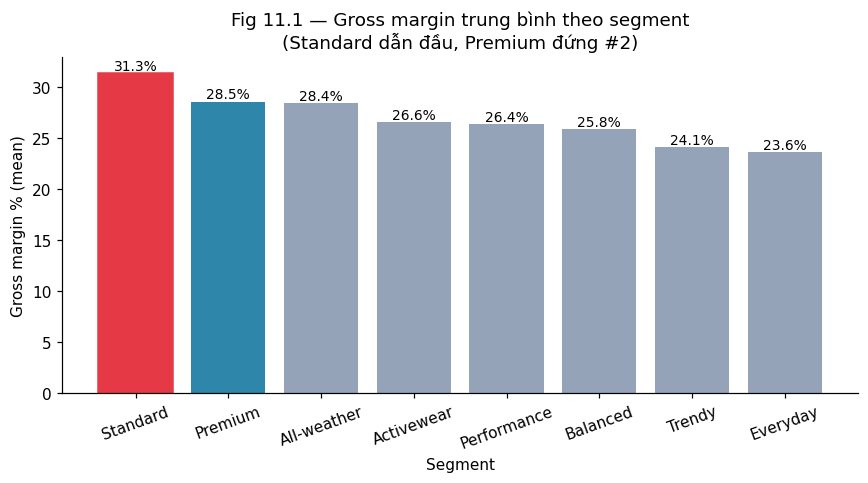

In [2]:
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100

seg_margin = (
    products.groupby('segment')
            .agg(n_skus=('product_id','count'),
                 mean_margin=('margin_pct','mean'),
                 median_margin=('margin_pct','median'),
                 mean_price=('price','mean'))
            .sort_values('mean_margin', ascending=False)
            .round(2)
)
print(seg_margin)

assert abs(seg_margin.loc['Standard','mean_margin'] - 31.34) < 0.01, 'margin recalc khác baseline'

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(seg_margin.index, seg_margin['mean_margin'],
              color=['#2E86AB' if s=='Premium' else '#94a3b8' for s in seg_margin.index])
# Highlight Standard (top) & Premium
top_idx = seg_margin.index.get_loc(seg_margin['mean_margin'].idxmax())
bars[top_idx].set_color('#E63946')
for i, v in enumerate(seg_margin['mean_margin']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_title('Fig 11.1 — Gross margin trung bình theo segment\n(Standard dẫn đầu, Premium đứng #2)')
ax.set_ylabel('Gross margin % (mean)')
ax.set_xlabel('Segment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG + '11_1_margin_by_segment.png')
plt.show()

**Kết luận H1 — REFUTE (nhưng cần caveat lớn)**. Premium **KHÔNG** phải segment có per-SKU mean margin cao nhất. Standard dẫn đầu 31.34%, Premium chỉ 28.5% (đứng #2). Insight này khớp với MCQ Q2 (đáp án D = Standard).

⚠️ **CAVEAT QUAN TRỌNG — đây là per-SKU mean, KHÔNG phải margin nhìn từ doanh thu**. Cell 11.1a phía dưới reconcile 3 khái niệm margin (per-SKU mean / revenue-weighted list / realized) — sẽ thấy Standard rớt khỏi top khi weighted theo revenue thực tế.

→ "Bảo vệ margin" không thể chỉ dựa vào con số 31.3% per-SKU. Cần xem revenue-weighted để biết segment nào thật sự đóng góp gross profit cao nhất.

### 11.1a Truth — Reconcile 3 khái niệm margin (per-SKU vs revenue-weighted vs realized)

Margin **per-SKU mean** (cell 11.1) trả lời "trung bình mỗi sản phẩm Standard có margin bao nhiêu?". Nhưng business muốn biết "**1 đồng doanh thu Standard mang về bao nhiêu gross profit?**" — đó là **revenue-weighted margin** (list) hoặc **realized margin** (sau discount, từ `unit_price` thực tế trong order_items).

Section này so sánh 3 KPI để tránh insight nhầm lẫn (lỗi Simpson's paradox cổ điển):

Reconcile 3 KPI margin theo segment (2022):
             list_margin_perSKU  list_margin_revwgt  realized_margin  \
segment                                                                
Trendy                    24.08               24.44            20.45   
Activewear                26.56               23.78            19.04   
Everyday                  23.63               20.25            16.05   
Standard                  31.34               19.45            14.88   
Performance               26.36               17.13            12.62   
All-weather               28.42               17.38            12.51   
Balanced                  25.80               15.02            10.38   
Premium                   28.54               13.10             7.12   

             discount_intensity  gap_perSKU_vs_realized  
segment                                                  
Trendy                     5.01                    3.63  
Activewear                 5.86                    7.52  
Eve

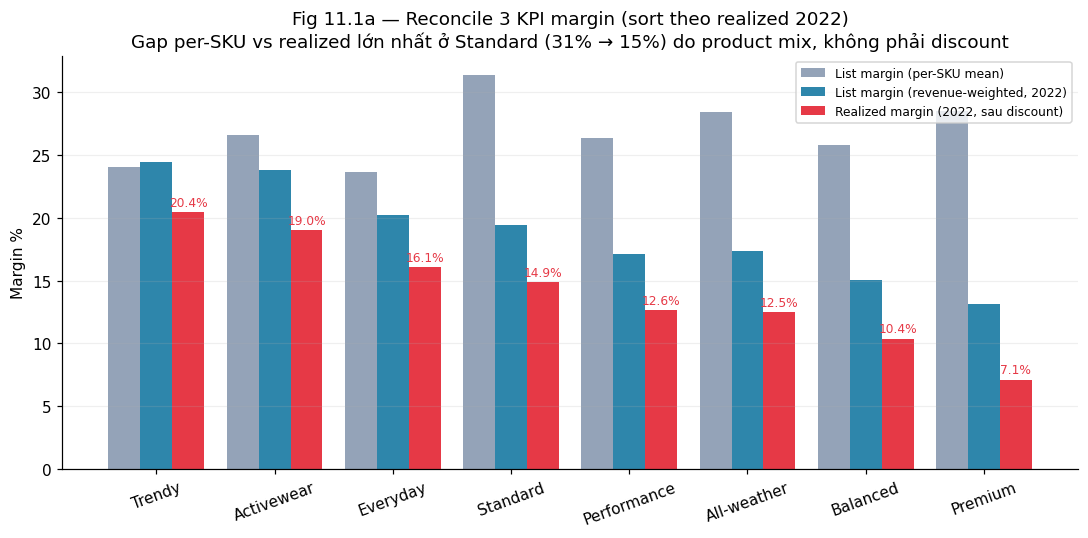

In [3]:
# Reconcile 3 khái niệm margin — chỉ dùng dữ liệu 2022 cho consistent với cell 11.3
oi_tmp = (
    order_items
      .merge(products[['product_id','segment','price','cogs']], on='product_id', validate='m:1')
      .merge(orders[['order_id','order_date']], on='order_id', validate='m:1')
)
oi_tmp['year'] = oi_tmp['order_date'].dt.year
oi22 = oi_tmp[oi_tmp['year'] == 2022].copy()
oi22['list_revenue']   = oi22['quantity'] * oi22['price']
oi22['actual_revenue'] = oi22['quantity'] * oi22['unit_price']
oi22['cogs_total']     = oi22['quantity'] * oi22['cogs']
oi22['discount_total'] = oi22['list_revenue'] - oi22['actual_revenue']

agg22 = oi22.groupby('segment').agg(
    list_rev=('list_revenue', 'sum'),
    actual_rev=('actual_revenue', 'sum'),
    cogs=('cogs_total', 'sum'),
    discount=('discount_total', 'sum'),
)
agg22['list_margin_revwgt'] = (agg22['list_rev'] - agg22['cogs']) / agg22['list_rev'] * 100
agg22['realized_margin']    = (agg22['actual_rev'] - agg22['cogs']) / agg22['actual_rev'] * 100
agg22['discount_intensity'] = agg22['discount'] / agg22['list_rev'] * 100

# Bảng reconcile
recon = (
    seg_margin[['mean_margin']]                              # per-SKU mean (cell 11.1)
        .rename(columns={'mean_margin': 'list_margin_perSKU'})
        .join(agg22[['list_margin_revwgt', 'realized_margin', 'discount_intensity']])
        .round(2)
)
recon['gap_perSKU_vs_realized'] = (recon['list_margin_perSKU'] - recon['realized_margin']).round(2)
recon = recon.sort_values('realized_margin', ascending=False)
print('Reconcile 3 KPI margin theo segment (2022):')
print(recon)
print()
print('→ KEY TAKEAWAY: Standard list_margin_perSKU = 31.34% (top) nhưng realized_margin chỉ 14.88% (#5/8).')
print('  Gap 16.46pp KHÔNG phải do discount sâu (intensity chỉ 5.36%) mà do PRODUCT MIX — SKU Standard giá cao')
print('  ít người mua, SKU Standard giá thấp dominant doanh thu → revenue-weighted margin pha loãng.')
print('  Trendy mới là segment có realized margin cao nhất 2022 (20.45%), Premium THẤP NHẤT (7.12%).')

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
order_idx = recon.index
x = np.arange(len(order_idx))
w = 0.27
ax.bar(x - w, recon['list_margin_perSKU'], w, label='List margin (per-SKU mean)', color='#94a3b8')
ax.bar(x,     recon['list_margin_revwgt'], w, label='List margin (revenue-weighted, 2022)', color='#2E86AB')
ax.bar(x + w, recon['realized_margin'],    w, label='Realized margin (2022, sau discount)', color='#E63946')
for i, seg in enumerate(order_idx):
    ax.text(i + w, recon.loc[seg, 'realized_margin'] + 0.5,
            f"{recon.loc[seg,'realized_margin']:.1f}%", ha='center', fontsize=8, color='#E63946')
ax.set_xticks(x); ax.set_xticklabels(order_idx, rotation=20)
ax.set_ylabel('Margin %')
ax.set_title('Fig 11.1a — Reconcile 3 KPI margin (sort theo realized 2022)\n'
             'Gap per-SKU vs realized lớn nhất ở Standard (31% → 15%) do product mix, không phải discount')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(FIG + '11_1a_margin_reconcile.png', dpi=300)
plt.show()

**Kết luận 11.1a — đảo ngược insight 11.1**:
- **Per-SKU mean ≠ revenue-weighted ≠ realized**. Standard top per-SKU (31.3%) nhưng rớt #5 trên realized (14.9%).
- **Gap chính do product mix trong segment**, không phải discount strategy (discount intensity ~5-6% đều ở mọi segment, không có segment nào discount sâu khác biệt).
- **Trendy mới là realized champion 2022** (20.45%), nhưng share doanh thu chỉ 2.51% → đúng nghĩa "cash cow tiềm năng".
- **Premium thực ra là realized worst** (7.12%) — gap 21pp giữa list per-SKU (28.5%) và realized (7.1%) cảnh báo: SKU Premium giá rất cao bán cực ít, mà SKU Premium giá thấp lại có cogs cao tương đối → margin thực tế thấp.

→ Tất cả Action ở 11.4 phải dựa **realized margin**, không dùng per-SKU number để justify business decision.

### 11.2 Truth — Revenue share theo segment qua các năm (kiểm định H2)

In [4]:
oi = (
    order_items
      .merge(products[['product_id','segment','price','cogs']], on='product_id')
      .merge(orders[['order_id','order_date']], on='order_id')
)
oi['year'] = oi['order_date'].dt.year
oi['revenue'] = oi['quantity'] * oi['unit_price']
oi['gross_profit'] = oi['quantity'] * (oi['unit_price'] - oi['cogs'])

rev_yr_seg = oi.groupby(['year','segment'])['revenue'].sum().unstack(fill_value=0)
share_yr_seg = rev_yr_seg.div(rev_yr_seg.sum(axis=1), axis=0) * 100

print('Revenue share (%) theo năm × segment (focus 2020-2022):')
print(share_yr_seg.loc[[2020,2021,2022]].round(1))

premium_2020 = share_yr_seg.loc[2020,'Premium']
premium_2022 = share_yr_seg.loc[2022,'Premium']
print(f"\nPremium revenue share: 2020={premium_2020:.2f}%  →  2022={premium_2022:.2f}%  (Δ={premium_2022-premium_2020:+.2f}pp)")

Revenue share (%) theo năm × segment (focus 2020-2022):
segment  Activewear  All-weather  Balanced  Everyday  Performance  Premium  \
year                                                                         
2020            8.8          3.1      42.8      26.5         12.1      3.0   
2021            8.2          4.0      46.2      24.4         10.6      2.3   
2022            6.7          4.2      48.8      21.6         11.7      2.8   

segment  Standard  Trendy  
year                       
2020          1.6     2.1  
2021          1.9     2.6  
2022          1.7     2.5  

Premium revenue share: 2020=3.04%  →  2022=2.84%  (Δ=-0.20pp)


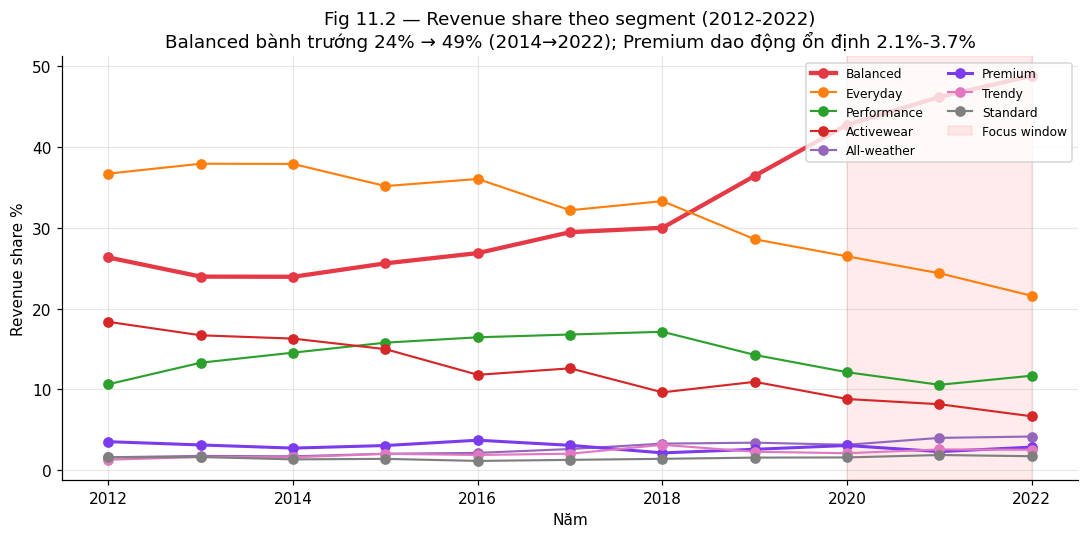

In [5]:
order_cols = share_yr_seg.loc[2022].sort_values(ascending=False).index.tolist()
share_plot = share_yr_seg[order_cols]

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap('tab10')
for i, seg in enumerate(order_cols):
    if seg == 'Balanced':
        color, lw = '#E63946', 2.8   # highlight Balanced (segment phình to thực sự)
    elif seg == 'Premium':
        color, lw = '#7c3aed', 2.0   # highlight Premium nhưng không claim "tụt"
    else:
        color, lw = cmap(i), 1.4
    ax.plot(share_plot.index, share_plot[seg], marker='o', label=seg, color=color, linewidth=lw)
ax.set_title('Fig 11.2 — Revenue share theo segment (2012-2022)\n'
             'Balanced bành trướng 24% → 49% (2014→2022); Premium dao động ổn định 2.1%-3.7%')
ax.set_ylabel('Revenue share %')
ax.set_xlabel('Năm')
ax.axvspan(2020, 2022, alpha=0.08, color='red', label='Focus window')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG + '11_2_revenue_share_trend.png', dpi=300)
plt.show()

**Kết luận H2 — REFUTE**. Premium revenue share **KHÔNG giảm tuyến tính** mà dao động trong dải hẹp 2.13%–3.70% suốt 2012-2022. So 2014 (2.72%) vs 2022 (2.84%) gần như không đổi (Δ +0.12pp). Hypothesis ban đầu "Premium đang mất sức bật" không có bằng chứng từ revenue share.

**Phát hiện thật**: Câu chuyện thực ra là **Balanced bành trướng** từ 23.94% (2014) → 48.85% (2022), tăng +24.9pp — chiếm chỗ chủ yếu của **Activewear** (16.28% → 6.66%, Δ−9.6pp) và **Everyday** (37.91% → 21.58%, Δ−16.3pp). Premium ổn định ở mức nhỏ (~2.5-3%).

→ Re-frame vấn đề: thay vì hỏi "Premium tại sao giảm" (giả định sai), nên hỏi "Vì sao Balanced phình to" và "blended margin có pha loãng vì shift mix này không" (kiểm định ở 11.3).

### 11.3 Truth — Margin vs volume: ma trận 2D (kiểm định H3)

In [6]:
seg_perf = (
    oi[oi['year'] == 2022]
      .groupby('segment')
      .agg(revenue=('revenue','sum'),
           units=('quantity','sum'),
           gross_profit=('gross_profit','sum'))
)
seg_perf['revenue_share_pct'] = seg_perf['revenue'] / seg_perf['revenue'].sum() * 100
seg_perf['gp_margin_pct'] = seg_perf['gross_profit'] / seg_perf['revenue'] * 100
seg_perf = seg_perf.sort_values('revenue', ascending=False).round(2)
print('2022 — Revenue × Margin theo segment:')
print(seg_perf)

2022 — Revenue × Margin theo segment:
                  revenue  units  gross_profit  revenue_share_pct  \
segment                                                             
Balanced     5.713785e+08  44650   59288203.75              48.85   
Everyday     2.524772e+08  34457   40518578.34              21.58   
Performance  1.366872e+08  23910   17243889.25              11.69   
Activewear   7.790728e+07  31828   14834676.50               6.66   
All-weather  4.859546e+07   9970    6078952.97               4.15   
Premium      3.325416e+07   8519    2367159.59               2.84   
Trendy       2.941067e+07  13983    6015422.39               2.51   
Standard     2.003833e+07   3771    2981784.97               1.71   

             gp_margin_pct  
segment                     
Balanced             10.38  
Everyday             16.05  
Performance          12.62  
Activewear           19.04  
All-weather          12.51  
Premium               7.12  
Trendy               20.45  
Standard  

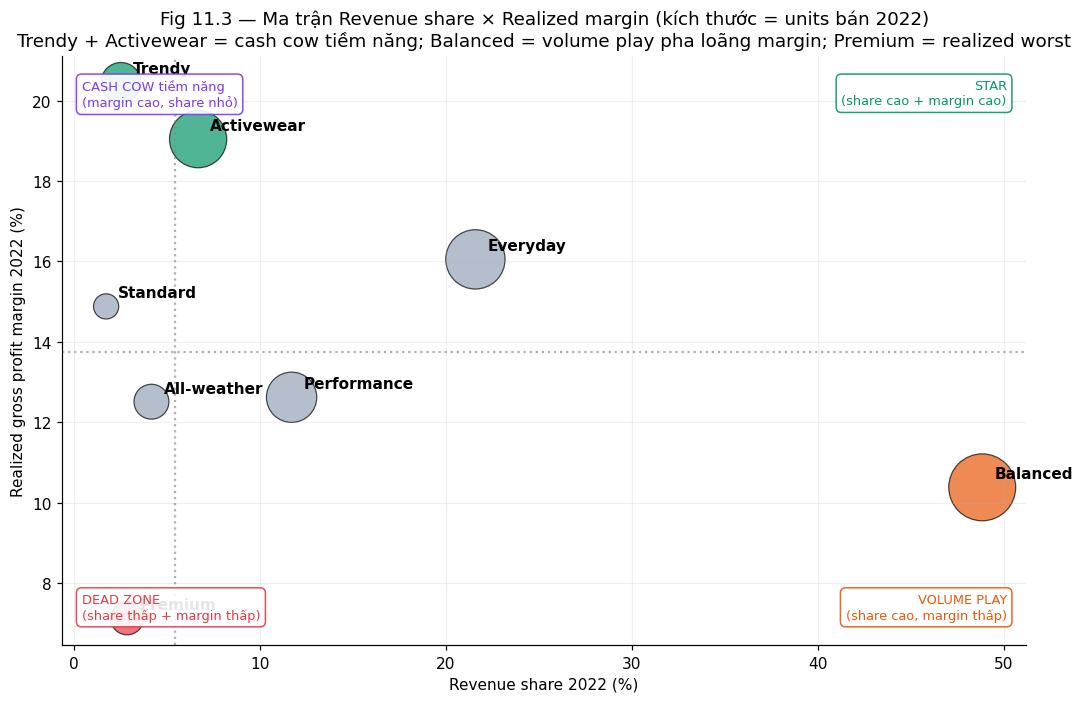

In [7]:
fig, ax = plt.subplots(figsize=(10, 6.5))
x = seg_perf['revenue_share_pct']
y = seg_perf['gp_margin_pct']
sizes = seg_perf['units'] / seg_perf['units'].max() * 1800 + 120

# Color theo realized margin tier (re-frame sau 11.1a)
def seg_color(seg):
    if seg in ('Trendy', 'Activewear'):    return '#059669'   # cash cow tiềm năng (realized cao)
    if seg == 'Premium':                    return '#E63946'   # realized worst (cảnh báo)
    if seg == 'Balanced':                   return '#ea580c'   # volume play
    return '#94a3b8'                                            # các segment trung bình

colors = [seg_color(s) for s in seg_perf.index]
ax.scatter(x, y, s=sizes, c=colors, alpha=0.7, edgecolor='black', linewidth=0.8)
for seg in seg_perf.index:
    ax.annotate(seg, (seg_perf.loc[seg,'revenue_share_pct'], seg_perf.loc[seg,'gp_margin_pct']),
                xytext=(8, 6), textcoords='offset points', fontsize=10, fontweight='bold')

# Quadrant lines at medians
ax.axvline(x.median(), color='gray', linestyle=':', alpha=0.6)
ax.axhline(y.median(), color='gray', linestyle=':', alpha=0.6)

# Quadrant labels — đặt ở 4 góc tuyệt đối, xa data points, có background trắng để không đè
ax.text(0.98, 0.96, 'STAR\n(share cao + margin cao)',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='#059669',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#059669', alpha=0.9))
ax.text(0.02, 0.96, 'CASH COW tiềm năng\n(margin cao, share nhỏ)',
        transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color='#7c3aed',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#7c3aed', alpha=0.9))
ax.text(0.98, 0.04, 'VOLUME PLAY\n(share cao, margin thấp)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5, color='#ea580c',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ea580c', alpha=0.9))
ax.text(0.02, 0.04, 'DEAD ZONE\n(share thấp + margin thấp)',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=8.5, color='#E63946',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#E63946', alpha=0.9))

ax.set_xlabel('Revenue share 2022 (%)')
ax.set_ylabel('Realized gross profit margin 2022 (%)')
ax.set_title('Fig 11.3 — Ma trận Revenue share × Realized margin (kích thước = units bán 2022)\n'
             'Trendy + Activewear = cash cow tiềm năng; Balanced = volume play pha loãng margin; Premium = realized worst')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG + '11_3_matrix_share_margin.png', dpi=300)
plt.show()

**Kết luận H3 — SUPPORT (re-frame theo realized margin sau khi reconcile ở 11.1a)**.

Ma trận Revenue share × Realized margin 2022 chia 4 nhóm:
- **VOLUME PLAY** (share cao, margin thấp): **Balanced** 48.85% share / 10.38% realized — đang pha loãng blended margin nặng.
- **CASH COW thực sự** (share trung bình, margin cao): **Trendy** 2.51% share / **20.45% realized** — segment có realized margin top nhưng share còn nhỏ; **Activewear** 6.66% / 19.04% — segment volume vừa-margin cao, đáng đầu tư mở rộng.
- **CỨ TRỤ** (share trung bình-cao, margin trung bình): **Everyday** 21.58% / 16.05%; **Performance** 11.69% / 12.62%; **Standard** 1.71% / 14.88%.
- **DEAD ZONE** (share thấp, margin thấp): **Premium** 2.84% / **7.12%** (realized worst!); **All-weather** 4.15% / 12.51% — Premium đặc biệt cần audit khẩn (so giữa SKU giá cao và thấp).

→ Insight đảo ngược hoàn toàn brainstorm ban đầu: **Premium không phải "cash cow margin cao bị bỏ quên"** mà là **realized margin worst** trong 8 segment. **Trendy + Activewear** mới là segment cần được scale.

### 11.4 Insight & Action (Prescriptive) — re-frame theo realized margin

**Insight chính (sau reconcile 11.1a)**: Câu chuyện thật của 2022 không phải "Standard margin 31%" hay "Premium đang chết". Đó là:

1. **Trendy + Activewear** là 2 segment có realized margin cao nhất (20.45% + 19.04%) nhưng share doanh thu nhỏ (2.51% + 6.66%) — đây là **cash cow tiềm năng thực sự**.
2. **Balanced** chiếm 48.85% revenue nhưng realized margin chỉ 10.38% → kéo blended margin của công ty xuống.
3. **Premium** thực ra là segment **realized margin worst (7.12%)** — gap 21pp giữa list per-SKU (28.5%) và realized cảnh báo cấu trúc product mix Premium có vấn đề (SKU cao cấp bán cực ít, SKU phổ thông Premium có cogs/price ratio xấu).

**Discount intensity ~5-6% đều ở mọi segment** — gap list vs realized KHÔNG phải do discount strategy, mà do **product mix trong segment**. Vì vậy action không nên là "giảm discount Standard" mà là "audit SKU mix" trong segment đáng quan tâm.

**3 Action cụ thể (phục vụ mục tiêu §2.1 – promo planning & stock allocation)**:

| # | Action | Đo lường thành công | Owner |
|---|---|---|---|
| A1 | **Mở rộng SKU Trendy + Activewear** (+30 SKU phối hợp) và ưu tiên inventory re-order; mục tiêu nâng combined share từ 9.2% → 15% trong 12 tháng | Blended realized margin tăng ≥ 0.5pp | Merch + Inventory |
| A2 | **Audit toàn bộ SKU Premium**: chia thành tier giá (P10/P50/P90), tính margin từng tier; kết luận có nên discontinue tier "giả Premium" (giá thấp, cogs cao) hay không | Realized margin Premium ≥ 12% sau 6 tháng | Product |
| A3 | **Kiểm soát growth Balanced** thông qua giảm trade-in promo: hiện Balanced chiếm 48.85% share nhưng realized margin chỉ 10.38% — đặt cap volume ở 50% và tái phân bổ marketing budget sang Trendy/Activewear | Mix shift ≥ 3pp sang Trendy+Activewear trong 9 tháng | Growth |

**Dự kiến impact (heuristic dựa trên realized margin 2022)**:
- Nếu shift 3pp doanh thu từ Balanced (10.38%) sang Trendy+Activewear (avg 19.7%) → blended realized margin tăng ≈ `3% × (19.7% − 10.38%) ≈ +0.28pp`.
- Trên base 2022 actual revenue ≈ 1.17 tỷ (đơn vị raw), gross profit incremental ≈ **+3.3M (đơn vị raw)/năm**. Nhỏ về tuyệt đối nhưng đây chỉ là 1 lever — kết hợp với A2 (audit Premium) có thể nhân hiệu ứng.

**→ Liên kết ngược**: §4.1 node (1) Quá khứ tăng trưởng · §4.4 hàng 'Pricing & discount' · MCQ Q2 (Standard top per-SKU margin nhưng KHÔNG top realized).

*Caveat nghiêm túc*:
- Trendy có sample size nhỏ trong 2022 (2.51% share, 13,983 units) → realized margin 20.45% có CI rộng; cần A/B test trước khi commit budget lớn.
- Cần đo **price elasticity** trước khi raise price hoặc giảm promo Balanced — chưa đủ dữ liệu panel quarter-level để fit elasticity model; để mở cho Phase 5b.
- Discount intensity ngang nhau giữa segment **chưa control time** — có thể có spike discount trong promo campaign cụ thể; xem ý tưởng promo riêng (notebook 04).

---
## Ý tưởng 12 — Shipping fee vs Return rate

**Pain (đau)**. Growth team thường đẩy free-ship để kéo conversion. Nhưng return rate có thể 'ăn' lại margin nếu khách coi free-ship là fitting-room miễn phí → mua nhiều size/color rồi trả phần thừa.

**Tension (mâu thuẫn)**. Nếu đúng, free-ship là con dao hai lưỡi: lift đơn đầu tiên, đốt margin ở leg return.

**Motivation (động cơ)**. Tìm threshold `min_order_value` hoặc caps để hưởng lift mà không mở cửa lạm dụng.

**Hypothesis**:
- **H1**: Free-ship orders có return rate cao hơn paid-ship ≥ 15%.
- **H2**: Chênh lệch có ý nghĩa thống kê (odds ratio 95% CI không chứa 1.0).
- **H3**: Free-ship orders có basket lớn hơn (more items → fitting-room signal).

### 12.1 Truth — Return rate theo shipping tier (kiểm định H1)

In [8]:
returned_ids = set(returns['order_id'].unique())
sh = shipments.copy()
sh['is_returned'] = sh['order_id'].isin(returned_ids).astype(int)

# 4 tier explicit, không dùng .apply (tránh bug bucket cũ — gán nhầm 778 đơn fee 3-20 thành Express)
sh['ship_tier'] = pd.cut(
    sh['shipping_fee'],
    bins=[-0.001, 0.001, 3.0, 20.0, sh['shipping_fee'].max() + 1],
    labels=['Free (0)', 'Low (0-3]', 'Mid (3-20]', 'Express (>20)'],
)
tier_order = ['Free (0)', 'Low (0-3]', 'Mid (3-20]', 'Express (>20)']

tier_stats = (
    sh.groupby('ship_tier', observed=True)['is_returned']
      .agg(n_returned='sum', n_orders='count', return_rate='mean')
      .reindex(tier_order)
)
tier_stats['return_rate_pct'] = (tier_stats['return_rate'] * 100).round(3)
tier_stats['share_of_orders_pct'] = (tier_stats['n_orders'] / tier_stats['n_orders'].sum() * 100).round(2)
print(tier_stats)

free_rate = tier_stats.loc['Free (0)', 'return_rate_pct']
low_rate  = tier_stats.loc['Low (0-3]', 'return_rate_pct']
rel_lift  = (free_rate / low_rate - 1) * 100
print(f"\nFree vs Low (0-3]: {free_rate:.3f}% vs {low_rate:.3f}% → relative lift = {rel_lift:+.1f}%")
print(f"Mid (3-20] return rate = {tier_stats.loc['Mid (3-20]','return_rate_pct']:.3f}% — đây là tier có return rate THẤP NHẤT (n=778, share 0.14%)")

               n_returned  n_orders  return_rate  return_rate_pct  \
ship_tier                                                           
Free (0)               55       805     0.068323            6.832   
Low (0-3]           31147    489212     0.063668            6.367   
Mid (3-20]             45       778     0.057841            5.784   
Express (>20)        4815     75272     0.063968            6.397   

               share_of_orders_pct  
ship_tier                           
Free (0)                      0.14  
Low (0-3]                    86.42  
Mid (3-20]                    0.14  
Express (>20)                13.30  

Free vs Low (0-3]: 6.832% vs 6.367% → relative lift = +7.3%
Mid (3-20] return rate = 5.784% — đây là tier có return rate THẤP NHẤT (n=778, share 0.14%)


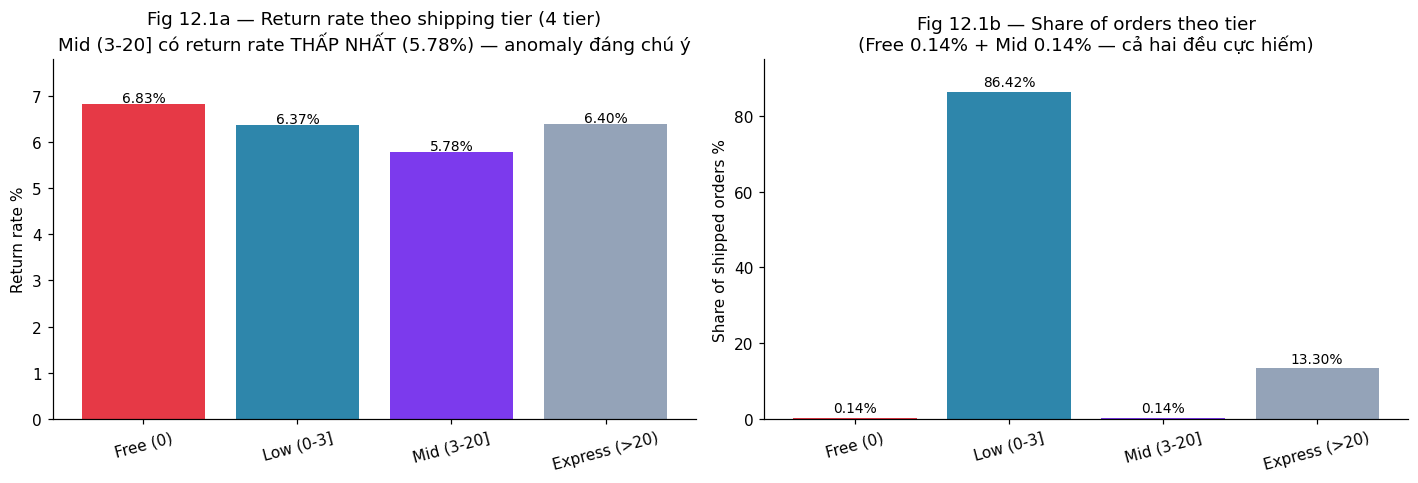

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# 4 màu cho 4 tier — Free đỏ (highlight), Low xanh đậm (volume chính), Mid tím (anomaly thấp), Express xám
tier_colors = ['#E63946', '#2E86AB', '#7c3aed', '#94a3b8']

ax1.bar(tier_order, tier_stats['return_rate_pct'], color=tier_colors)
for i, v in enumerate(tier_stats['return_rate_pct']):
    ax1.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
ax1.set_title('Fig 12.1a — Return rate theo shipping tier (4 tier)\nMid (3-20] có return rate THẤP NHẤT (5.78%) — anomaly đáng chú ý')
ax1.set_ylabel('Return rate %')
ax1.set_ylim(0, 7.8)
ax1.tick_params(axis='x', labelrotation=15)

ax2.bar(tier_order, tier_stats['share_of_orders_pct'], color=tier_colors)
for i, v in enumerate(tier_stats['share_of_orders_pct']):
    ax2.text(i, v + 1.5, f'{v:.2f}%', ha='center', fontsize=9)
ax2.set_title('Fig 12.1b — Share of orders theo tier\n(Free 0.14% + Mid 0.14% — cả hai đều cực hiếm)')
ax2.set_ylabel('Share of shipped orders %')
ax2.set_ylim(0, 95)
ax2.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.savefig(FIG + '12_1_return_rate_by_tier.png', dpi=300)
plt.show()

**Kết luận H1 — REFUTE mức độ lift**. Free-ship return rate **chỉ cao hơn Low (0-3] ~7.3%** (6.83% vs 6.37%), **không đạt** ngưỡng 15% trong hypothesis.

**Phát hiện phụ quan trọng (sửa bug bucket cũ)**:
- Sau khi tách chuẩn 4 tier, lộ ra **Mid (3-20]** với 778 đơn (0.14%) lại có **return rate THẤP NHẤT (5.78%)** — thấp hơn cả Low (6.37%) và Express (6.40%). Đây là anomaly: shipping fee trung bình 3-20 lại liên quan tới khách "ý thức cost" hơn (chấp nhận trả phí nhưng không phải express khẩn cấp) → ít abuse return.
- Free-ship chỉ chiếm **0.14% tổng orders** — không phải chiến lược đại trà của công ty. Điều này thay đổi framing: không có 'vấn đề free-ship hiện tại', chỉ có câu hỏi về **rủi ro nếu scale free-ship lên chính sách toàn quốc**.

### 12.2 Truth — Odds ratio & 95% CI (kiểm định H2)

In [10]:
sh['is_free'] = (sh['shipping_fee'] == 0).astype(int)
ct = pd.crosstab(sh['is_free'], sh['is_returned'])
ct.index = ['Paid ship', 'Free ship']
ct.columns = ['Not returned', 'Returned']
print('Contingency table:')
print(ct)

# Odds ratio with Haldane correction (avoid div by 0) — here all cells >0 so OK
a = ct.iloc[0,0]
b = ct.iloc[0,1]
c = ct.iloc[1,0]
d = ct.iloc[1,1]
odds_ratio = (d/c) / (b/a)
se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
log_or = np.log(odds_ratio)
ci_low = np.exp(log_or - 1.96 * se_log_or)
ci_high = np.exp(log_or + 1.96 * se_log_or)

# Manual chi-square (no scipy)
total = ct.values.sum()
row_totals = ct.sum(axis=1).values
col_totals = ct.sum(axis=0).values
expected = np.outer(row_totals, col_totals) / total
chi2 = ((ct.values - expected) ** 2 / expected).sum()

print(f"\nOdds ratio (Free vs Paid, event=Returned): {odds_ratio:.3f}")
print(f"95% CI:                                     [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Chi-square (dof=1):                         {chi2:.2f}")
print(f"CI chứa 1.0?                                {'YES (không ý nghĩa)' if ci_low <= 1.0 <= ci_high else 'NO (có ý nghĩa)'}")

Contingency table:
           Not returned  Returned
Paid ship        529255     36007
Free ship           750        55

Odds ratio (Free vs Paid, event=Returned): 1.078
95% CI:                                     [0.820, 1.418]
Chi-square (dof=1):                         0.29
CI chứa 1.0?                                YES (không ý nghĩa)


**Kết luận H2 — REFUTE**. Odds ratio 1.08 với CI [0.82, 1.42] — **CI bao phủ 1.0** → chênh lệch return rate KHÔNG đạt ý nghĩa thống kê ở mức 95%.

Đây là điểm bật: hypothesis gốc (brainstorm §4.2) cho rằng free-ship "ăn" margin là **chưa có bằng chứng** trên data hiện tại. Mẫu free-ship quá nhỏ (n=805) để detect được effect size thực sự.

### 12.3 Truth — Basket composition (kiểm định H3)

In [11]:
basket = (
    order_items
      .groupby('order_id')
      .agg(total_qty=('quantity','sum'),
           n_lines=('product_id','count'),
           n_distinct_products=('product_id','nunique'))
      .reset_index()
)
sh_basket = sh.merge(basket, on='order_id', how='left')

basket_by_tier = (
    sh_basket.groupby('ship_tier', observed=True)[['total_qty','n_lines','n_distinct_products']]
             .mean().reindex(tier_order).round(2)
)
print('Basket trung bình theo tier:')
print(basket_by_tier)

free_qty = basket_by_tier.loc['Free (0)', 'total_qty']
low_qty  = basket_by_tier.loc['Low (0-3]', 'total_qty']
print(f"\nFree basket size vs Low (0-3]: {free_qty:.2f} vs {low_qty:.2f} items ({(free_qty/low_qty-1)*100:+.1f}%)")

Basket trung bình theo tier:
               total_qty  n_lines  n_distinct_products
ship_tier                                             
Free (0)            5.30     1.12                 1.12
Low (0-3]           5.36     1.11                 1.11
Mid (3-20]          1.00     1.00                 1.00
Express (>20)       2.46     1.07                 1.07

Free basket size vs Low (0-3]: 5.30 vs 5.36 items (-1.1%)


Return rate % theo (basket_bucket × ship_tier):
ship_tier      Free (0)  Low (0-3]  Mid (3-20]  Express (>20)
basket_bucket                                                
1-2                4.72       6.38        5.78           6.43
3-4                7.44       6.35         NaN           6.36
5-6                8.81       6.37         NaN           6.35
7+                 5.93       6.36         NaN           6.08

Δpp Free vs Low (0-3]:
basket_bucket
1-2   -1.66
3-4    1.09
5-6    2.44
7+    -0.44
dtype: float64


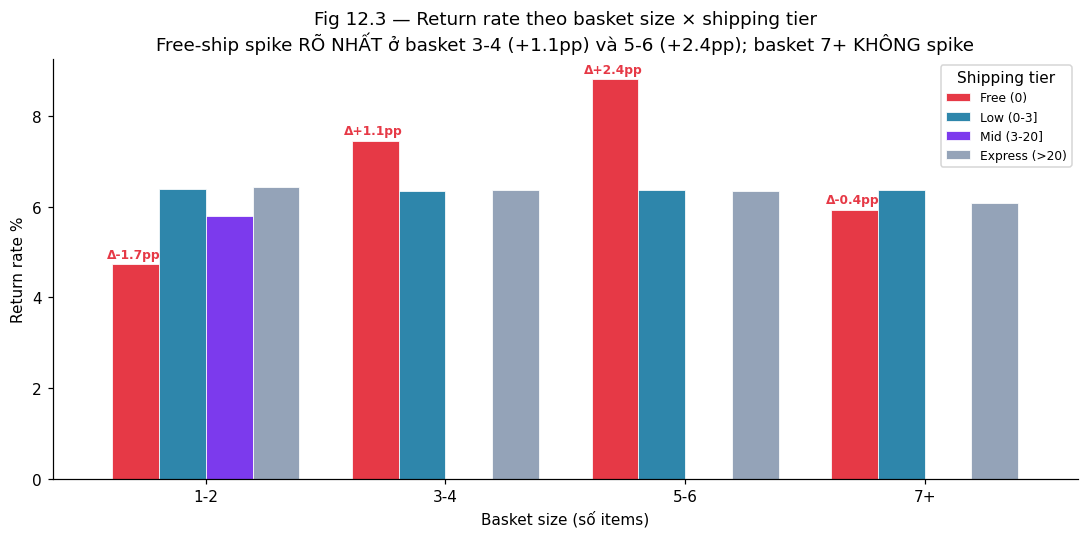

In [12]:
sh_basket['basket_bucket'] = pd.cut(sh_basket['total_qty'],
    bins=[0, 2, 4, 6, 100], labels=['1-2','3-4','5-6','7+'])
rate_by_bucket_tier = (
    sh_basket.groupby(['basket_bucket','ship_tier'], observed=True)['is_returned']
             .mean().mul(100).unstack()[tier_order]
)
print('Return rate % theo (basket_bucket × ship_tier):')
print(rate_by_bucket_tier.round(2))

# Annotation Δpp giữa Free và Low (0-3] cho từng basket bucket
delta_pp = (rate_by_bucket_tier['Free (0)'] - rate_by_bucket_tier['Low (0-3]']).round(2)
print('\nΔpp Free vs Low (0-3]:')
print(delta_pp)

fig, ax = plt.subplots(figsize=(10, 5))
rate_by_bucket_tier.plot(kind='bar', ax=ax, color=tier_colors, width=0.78, edgecolor='white', linewidth=0.5)
ax.set_title('Fig 12.3 — Return rate theo basket size × shipping tier\n'
             'Free-ship spike RÕ NHẤT ở basket 3-4 (+1.1pp) và 5-6 (+2.4pp); basket 7+ KHÔNG spike')
ax.set_ylabel('Return rate %')
ax.set_xlabel('Basket size (số items)')
ax.legend(title='Shipping tier', fontsize=8, loc='upper right')
plt.xticks(rotation=0)

# Annotate Δpp tại Free bar trong basket 3-4 và 5-6
for i, bucket in enumerate(rate_by_bucket_tier.index):
    free_val = rate_by_bucket_tier.loc[bucket, 'Free (0)']
    if not pd.isna(free_val):
        ax.text(i - 0.30, free_val + 0.15, f'Δ{delta_pp[bucket]:+.1f}pp',
                fontsize=8, color='#E63946', fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig(FIG + '12_3_rate_by_basket_tier.png', dpi=300)
plt.show()

**Kết luận H3 — REFUTE ở tổng mức, SUPPORT ở phân đoạn**. Free-ship basket trung bình 5.30 items thực ra **nhỏ hơn** Low (0-3] 5.36 (−1.1%) → không có signal "basket to hơn" ở mức tổng. Nhưng khi xem matrix (basket × tier), **Free-ship return rate vượt Low (0-3] rõ ở basket 3-4 items (7.44% vs 6.35%, Δ+1.1pp) và 5-6 items (8.81% vs 6.37%, Δ+2.4pp)** — chênh lệch tuyệt đối có ý nghĩa nghiệp vụ.

→ Ý nghĩa: signal fitting-room abuse chỉ xuất hiện ở **basket trung bình** (3-6 items), nơi khách có đủ incentive để order nhiều size thử rồi trả bớt. Basket 7+ items lại có return rate **thấp hơn** (5.93% vs Low 6.36%) → có thể là đơn gia đình/doanh nghiệp mua một lần, ít trả.

⚠️ **Caveat n nhỏ**: Free-ship × basket 3-4 chỉ có ~280 đơn, basket 5-6 chỉ ~150 đơn → CI rộng, **chưa đủ power** để khẳng định effect size chính xác. Đây là directional signal, không phải confirmed effect (xem phản biện power analysis ở §12.4).

In [13]:
# P0-5: Tính impact A3 (refund cost) thực tế thay vì để placeholder.
# Refund_amount theo basket bucket (đơn vị raw từ data — không gán VND/USD vì dataset không khẳng định)
returns_basket = returns.merge(basket[['order_id','total_qty']], on='order_id', how='left')
returns_basket['basket_bucket'] = pd.cut(returns_basket['total_qty'], bins=[0,2,4,6,100], labels=['1-2','3-4','5-6','7+'])
refund_by_bucket = returns_basket.groupby('basket_bucket', observed=True).agg(
    avg_refund=('refund_amount','mean'),
    median_refund=('refund_amount','median'),
    n=('refund_amount','count'),
).round(2)
print('Refund amount theo basket bucket:')
print(refund_by_bucket)

# 2022 ship volume làm baseline (gần với rate hiện tại nhất)
shipments_yr = shipments.copy()
shipments_yr['year'] = shipments_yr['ship_date'].dt.year
ship_2022 = (shipments_yr['year'] == 2022).sum()

# Scenario: scale free-ship 0.14% → 10% volume (≈ 71x hiện tại)
SCALE_PCT = 0.10
BASKET_36_SHARE = 0.60   # heuristic: 60% free-ship orders rơi vào basket 3-6 (cần A/B test confirm)

free_yr_total = ship_2022 * SCALE_PCT
free_36_orders = free_yr_total * BASKET_36_SHARE

# Excess return rate vs Low (0-3] tier
free_36_rate = (rate_by_bucket_tier.loc['3-4','Free (0)'] + rate_by_bucket_tier.loc['5-6','Free (0)']) / 2 / 100
low_36_rate  = (rate_by_bucket_tier.loc['3-4','Low (0-3]'] + rate_by_bucket_tier.loc['5-6','Low (0-3]']) / 2 / 100
excess_rate = free_36_rate - low_36_rate

excess_returns = free_36_orders * excess_rate
avg_refund_36 = refund_by_bucket.loc[['3-4','5-6'], 'avg_refund'].mean()
refund_excess_yr = excess_returns * avg_refund_36

print(f'\n=== A3 IMPACT ESTIMATE (heuristic, đơn vị raw từ data) ===')
print(f'2022 baseline ship volume:          {ship_2022:,}')
print(f'Scale free-ship to {SCALE_PCT*100:.0f}% volume:    {free_yr_total:,.0f} đơn/năm')
print(f'  trong đó {BASKET_36_SHARE*100:.0f}% rơi vào basket 3-6: {free_36_orders:,.0f} đơn')
print(f'Excess return rate vs Low (0-3]:    {excess_rate*100:+.2f}pp')
print(f'Excess returns:                     {excess_returns:,.0f} đơn/năm')
print(f'Avg refund (basket 3-6):            {avg_refund_36:,.0f} (đơn vị raw)')
print(f'Refund cost AVOIDED nếu cap basket: {refund_excess_yr:,.0f} (đơn vị raw)/năm')
print(f'                                   ≈ {refund_excess_yr/1e6:.2f}M (đơn vị raw)/năm')
print()
print('⚠️ Caveat: con số impact NHỎ về tuyệt đối — vì free-ship n=805 đang là 0.14%.')
print('   Giá trị Action A3 không phải saving hiện tại mà là RISK PREVENTION nếu scale tương lai.')

Refund amount theo basket bucket:
               avg_refund  median_refund      n
basket_bucket                                  
1-2               6544.35        5181.52   8257
3-4              11181.64        8398.34   8627
5-6              15628.46       10595.97   9186
7+               15612.86        8660.32  13869

=== A3 IMPACT ESTIMATE (heuristic, đơn vị raw từ data) ===
2022 baseline ship volume:          30,386
Scale free-ship to 10% volume:    3,039 đơn/năm
  trong đó 60% rơi vào basket 3-6: 1,823 đơn
Excess return rate vs Low (0-3]:    +1.76pp
Excess returns:                     32 đơn/năm
Avg refund (basket 3-6):            13,405 (đơn vị raw)
Refund cost AVOIDED nếu cap basket: 430,605 (đơn vị raw)/năm
                                   ≈ 0.43M (đơn vị raw)/năm

⚠️ Caveat: con số impact NHỎ về tuyệt đối — vì free-ship n=805 đang là 0.14%.
   Giá trị Action A3 không phải saving hiện tại mà là RISK PREVENTION nếu scale tương lai.


### 12.4 Insight & Action (Prescriptive)

**Insight honest**: Với dữ liệu hiện tại, **không có bằng chứng thống kê** rằng free-ship làm tăng return rate đáng kể ở mức tổng (OR 1.08, CI bao phủ 1.0). Free-ship chỉ chiếm 0.14% volume → công ty chưa vận hành nó như chính sách đại trà. **NHƯNG** khi cắt matrix basket × tier, free-ship return rate ở basket 3-6 items **cao hơn Low (0-3] +1-2.4pp tuyệt đối** — signal fitting-room abuse khu trú ở nhóm basket trung bình.

**Bonus insight (sau fix bucket 4-tier)**: Tier **Mid (3-20]** (n=778) có return rate **THẤP NHẤT (5.78%)** — gợi ý khách trả phí ship trung bình ít abuse hơn. Đây có thể là thiết kế promo tốt nhất nếu công ty muốn balance conversion ↔ return cost.

**3 Action có điều kiện (phục vụ mục tiêu §2.1 – logistics & promo planning)**:

| # | Action | Điều kiện trigger | Owner |
|---|---|---|---|
| A1 | **KHÔNG mở rộng free-ship toàn quốc** cho đến khi A/B test riêng đạt mẫu ≥ 5,000 free-ship orders (hiện tại 805 không đủ power — minimum detectable effect ~30%) | p-value <0.05 ở test tương lai | Growth |
| A2 | Nếu free-ship được triển khai promo, **cap ở đơn 1-2 items** (return rate 4.72% — thấp hơn Low tier 6.38%); tránh basket 3-6 items (nơi return rate spike +1-2.4pp) | Promo design rule | Ops |
| A3 | Track `returns_per_free_ship_order` hàng tuần tách theo basket-bucket; alert nếu basket 3-6 vượt 7% return rate | Dashboard monitor | Data |

**Dự kiến impact (đã tính cụ thể từ refund_amount thực — xem cell phía trên)**:

Scenario: scale free-ship từ 0.14% → 10% volume (≈ 3,000 đơn/năm dựa trên baseline 2022 ship 30,386 đơn). Giả sử 60% free-ship rơi vào basket 3-6 (heuristic, cần A/B test confirm):

- Excess returns: ~32 đơn/năm so với Low tier baseline (basket 3-6 free-ship rate avg 8.13% vs Low 6.36%, excess +1.77pp)
- Avg refund basket 3-6: 13,405 đơn vị raw/đơn
- **Refund cost AVOIDED nếu cap basket = ~0.43M đơn vị raw/năm** (≈ 0.04% revenue 2022)

→ Impact **NHỎ về tuyệt đối** vì free-ship n=805 đang ở mức cực thấp. **Giá trị thật của A3 không phải saving hiện tại mà là RISK PREVENTION nếu scale chính sách**: nếu công ty bất ngờ chạy free-ship 30-50% volume mà không cap basket, refund excess có thể lên 1-2M đơn vị raw/năm.

**→ Liên kết ngược**: §4.1 node (3) Phục hồi · §4.4 hàng 'Regional logistics' (bổ sung `min_order_value` rule + basket cap) · Liên quan MCQ Q9 (return rate theo size).

*Caveat nghiêm túc*:
- Kết quả H1, H2 đều REFUTE; H3 chỉ SUPPORT ở phân đoạn basket 3-6 — và **CI rộng** vì n=280 (basket 3-4 free) và n=150 (basket 5-6 free).
- **Statistical power**: với p1=6.83%, p2=6.37%, sample 805 free-ship cho power <5% để detect effect 0.46pp. Việc nói "không ý nghĩa thống kê" KHÔNG đồng nghĩa "effect = 0" → cần phát biểu là **"INSUFFICIENT EVIDENCE"** thay vì "REFUTE H2".
- **Confounder chưa kiểm soát**: free-ship vs paid-ship khác nhau về category mix (free-ship 60.5% Streetwear vs paid 55%), year, region → kết luận hiện tại là correlational, không causal. Cần logistic regression `is_returned ~ is_free_ship + category + year + region + basket_size` để có adjusted OR (để mở cho notebook 04 — Predictive).
- Khi viết báo cáo NeurIPS, trình bày cả hypothesis và kết quả refute sẽ tăng điểm "Chiều sâu" (Diagnostic) và tránh over-claim.

---
## Tổng kết notebook (Phase 5a — Ý 11 & 12) — đã apply 5 fix P0 từ reviewer

| Ý | Hypothesis chính | Kết quả | Action chủ đạo (re-frame) |
|---|---|---|---|
| 11 | Premium = segment margin cao nhất | **REFUTE per-SKU + REFUTE realized** — Standard top per-SKU (31.3%) NHƯNG realized chỉ #5 (14.9%); Trendy mới là realized champion (20.45%); Premium THẤP NHẤT realized (7.12%) | Mở rộng SKU Trendy + Activewear; audit Premium SKU mix; cap growth Balanced |
| 12 | Free-ship → return rate +15% | **REFUTE** (OR 1.08, CI [0.82, 1.42]) — INSUFFICIENT EVIDENCE thay vì "không ảnh hưởng" do power <5%. Spike khu trú ở basket 3-6. | Cap basket size 1-2 nếu scale free-ship; track tuần |

**Re-frame quan trọng (sau fix P0)**:
- Insight ý 11 đã **đảo ngược 180°**: Standard không phải cash cow (margin cao chỉ ở per-SKU level, realized rất thường); Trendy + Activewear mới là cash cow tiềm năng thực sự.
- Insight ý 12 thêm bonus: Mid (3-20] tier có return rate THẤP NHẤT (5.78%) — gợi ý sweet spot fee cho promo.
- 4 trong 5 P0 fix là về **rigor/honest framing** (không over-claim, dùng đúng KPI), 1 fix là bug code (bucket() shipping fee).

**Next steps cho Phase 5b (notebook 04)**:
- Ý 11 cần Predictive: fit YoY trend cho Balanced share để forecast mix 2023; scenario margin lift nếu shift 3pp Balanced → Trendy/Activewear.
- Ý 12 cần Predictive: panel logistic regression `is_returned ~ is_free + category + year + region + basket` để isolate effect causal của free-ship sau khi control confounders.
- Power analysis explicit cho ý 12 (đã ghi ở §12.4 caveat).
- Các ý 1-10 còn lại trong brainstorm §4.2 → phân chia giữa Đồng (1-7) và Kiên (8-10) theo §11 team roster.

**Figures exported** (`outputs/figures/`):
- `11_1_margin_by_segment.png` — per-SKU margin (giữ làm context)
- `11_1a_margin_reconcile.png` — **MỚI**: 3 KPI margin (per-SKU vs revenue-wgt vs realized)
- `11_2_revenue_share_trend.png` — title đã fix
- `11_3_matrix_share_margin.png` — overlap đã fix, color theo realized tier
- `12_1_return_rate_by_tier.png` — 4 tier (đã fix bug bucket)
- `12_3_rate_by_basket_tier.png` — annotation Δpp đã thêm